# 🍊 The Orange Problem — Multimodal Fine-Tuning
**Model:** Qwen2-VL-2B-Instruct | **Dataset:** ChartQA | **Hardware:** T4 GPU

In [27]:
!pip install -q transformers peft bitsandbytes accelerate datasets huggingface_hub
!pip install -q qwen-vl-utils matplotlib tqdm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 49.9 MB/s eta 0:00:00:00:0100:01


In [29]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
from tqdm import tqdm
from huggingface_hub import login
import os, gc, json

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [31]:
import os
from huggingface_hub import login

# Paste your HF token directly here for now
hf_token = "YOUR_HF_TOKEN_HERE"  # replace with your token, do not commit real tokens 

os.environ["HF_TOKEN"] = hf_token
login(token=hf_token)
print("Logged in!")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in!


In [42]:
# Config
BASE_MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
OUTPUT_DIR    = "/kaggle/working/lora_adapters"
HF_REPO_ID    = "Devildarker6789/qwen2vl-chartqa"  # ← CHANGE THIS

# BATCH_SIZE=1: OOM fix — T4 can't handle batch=2 for this model
# GRAD_ACCUM=16: effective batch = 1x16 = 16
# MAX_LENGTH=768: fits T4 with batch=1; 512 too short, 1024 OOM
# EPOCHS=1: full 2k subset; increase if you have time
EPOCHS         = 1
BATCH_SIZE     = 1
GRAD_ACCUM     = 16
LEARNING_RATE  = 2e-4
MAX_LENGTH     = 768
MAX_NEW_TOKENS = 64
TRAIN_SUBSET   = 2000
VAL_SUBSET     = 200

# r=16: balance between expressivity and memory for 2B model
# alpha=32: standard 2x rank scaling
# target q/k/v/o: most impactful projections for visual reasoning
LORA_RANK    = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
TARGET_MODS  = ["q_proj", "k_proj", "v_proj", "o_proj"]

# 28x28 = one patch. 512 patches max = T4 safe, enough detail for charts
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 512 * 28 * 28

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config ready")

Config ready


In [33]:
# Load Dataset
print("Loading ChartQA...")
raw_train = load_dataset("HuggingFaceM4/ChartQA", split="train").select(range(TRAIN_SUBSET))
raw_val   = load_dataset("HuggingFaceM4/ChartQA", split="val").select(range(VAL_SUBSET))
print(f"Train: {len(raw_train)} | Val: {len(raw_val)}")
print(f"Sample — Q: {raw_train[0]['query']} | A: {raw_train[0]['label']}")

Loading ChartQA...
Train: 2000 | Val: 200
Sample — Q: Is the value of Favorable 38 in 2015? | A: ['Yes']


In [34]:
# Load Model
# Why 8-bit? Qwen2-VL-2B in 8-bit = ~8GB VRAM, safe on T4.
# 4-bit causes shape mismatch bugs in Qwen2-VL's image merger.
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=False
)

print("Loading model...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)
processor = AutoProcessor.from_pretrained(
    BASE_MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS
)
print(f"Model loaded: {sum(p.numel() for p in model.parameters())/1e9:.2f}B params")

Loading model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Model loaded: 2.21B params


In [35]:
# Apply LoRA
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=TARGET_MODS,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable/1e6:.2f}M / {total/1e9:.2f}B ({100*trainable/total:.2f}%)")

Trainable: 4.36M / 2.21B (0.20%)


In [36]:
# Dataset and DataLoader
class ChartQADataset(Dataset):
    """
    Label masking: only the answer tokens get loss signal.
    Everything else (prompt, padding) is masked with -100.
    """
    def __init__(self, hf_dataset, processor, max_new_tokens=64, max_length=768):
        self.data       = hf_dataset
        self.processor  = processor
        self.max_tokens = max_new_tokens
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image  = sample["image"]
        if not isinstance(image, Image.Image): image = Image.fromarray(image)
        image = image.convert("RGB")

        label = sample["label"]
        if isinstance(label, list): label = label[0]
        label = str(label).strip()

        query = sample["query"]
        if isinstance(query, list): query = query[0]
        query = str(query).strip()

        messages = [{"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": query}
        ]}]
        prompt_text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        full_text   = prompt_text + label + self.processor.tokenizer.eos_token

        inputs = self.processor(
            text=[full_text], images=[image],
            return_tensors="pt", padding="max_length",
            max_length=self.max_length, truncation=True
        )

        input_ids      = inputs["input_ids"].squeeze(0)
        attention_mask = inputs["attention_mask"].squeeze(0)
        pixel_values   = inputs["pixel_values"]
        image_grid_thw = inputs["image_grid_thw"]

        # Mask all but the answer
        answer_ids = self.processor.tokenizer(
            label + self.processor.tokenizer.eos_token, return_tensors="pt"
        )["input_ids"].squeeze(0)
        n_answer = len(answer_ids)

        labels = torch.full_like(input_ids, -100)
        eos_pos = (input_ids == self.processor.tokenizer.eos_token_id).nonzero(as_tuple=True)[0]
        if len(eos_pos) > 0:
            last_eos = eos_pos[-1].item()
            start    = max(0, last_eos - n_answer + 1)
            labels[start:last_eos + 1] = input_ids[start:last_eos + 1]

        return {"input_ids": input_ids, "attention_mask": attention_mask,
                "pixel_values": pixel_values, "image_grid_thw": image_grid_thw, "labels": labels}


def collate_fn(batch):
    return {
        "input_ids":      torch.stack([b["input_ids"]      for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "pixel_values":   torch.cat([b["pixel_values"]     for b in batch], dim=0),
        "image_grid_thw": torch.cat([b["image_grid_thw"]   for b in batch], dim=0),
        "labels":         torch.stack([b["labels"]         for b in batch]),
    }


train_dataset = ChartQADataset(raw_train, processor, MAX_NEW_TOKENS, MAX_LENGTH)
val_dataset   = ChartQADataset(raw_val,   processor, MAX_NEW_TOKENS, MAX_LENGTH)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True, collate_fn=collate_fn)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True, collate_fn=collate_fn)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 2000 | Val batches: 200


In [37]:
# Training and validation functions
def train_one_epoch(model, loader, optimizer, scheduler, epoch, grad_accum):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    pbar = tqdm(loader, desc=f"Epoch {epoch} [Train]")
    for step, batch in enumerate(pbar):
        # Key fix: pass image_grid_thw directly to avoid shape mismatch errors
        outputs = model(
            input_ids=batch["input_ids"].to(DEVICE),
            attention_mask=batch["attention_mask"].to(DEVICE),
            pixel_values=batch["pixel_values"].to(DEVICE),
            image_grid_thw=batch["image_grid_thw"].to(DEVICE),
            labels=batch["labels"].to(DEVICE)
        )
        loss = outputs.loss / grad_accum
        loss.backward()
        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
        total_loss += outputs.loss.item()
        pbar.set_postfix({"loss": f"{outputs.loss.item():.4f}"})
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, epoch):
    model.eval()
    total_loss = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch} [Val]")
    for batch in pbar:
        outputs = model(
            input_ids=batch["input_ids"].to(DEVICE),
            attention_mask=batch["attention_mask"].to(DEVICE),
            pixel_values=batch["pixel_values"].to(DEVICE),
            image_grid_thw=batch["image_grid_thw"].to(DEVICE),
            labels=batch["labels"].to(DEVICE)
        )
        total_loss += outputs.loss.item()
        pbar.set_postfix({"val_loss": f"{outputs.loss.item():.4f}"})
    return total_loss / len(loader)

print("Training functions ready")

Training functions ready


In [38]:
# Run Training
optimizer   = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                lr=LEARNING_RATE, weight_decay=0.01)
total_steps = (len(train_loader) // GRAD_ACCUM) * EPOCHS
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
history     = {"train_loss": [], "val_loss": [], "epochs": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*50}\n  EPOCH {epoch}/{EPOCHS}\n{'='*50}")
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, epoch, GRAD_ACCUM)
    val_loss   = validate(model, val_loader, epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["epochs"].append(epoch)
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    ckpt = f"{OUTPUT_DIR}/epoch_{epoch}"
    model.save_pretrained(ckpt); processor.save_pretrained(ckpt)
    print(f"Saved: {ckpt}")

print("\nTraining complete!")


  EPOCH 1/1


Epoch 1 [Train]:   0%|          | 0/2000 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Epoch 1 [Val]:   0%|          | 0/200 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possibl

Train Loss: 0.5040 | Val Loss: 0.6956
Saved: /kaggle/working/lora_adapters/epoch_1

Training complete!


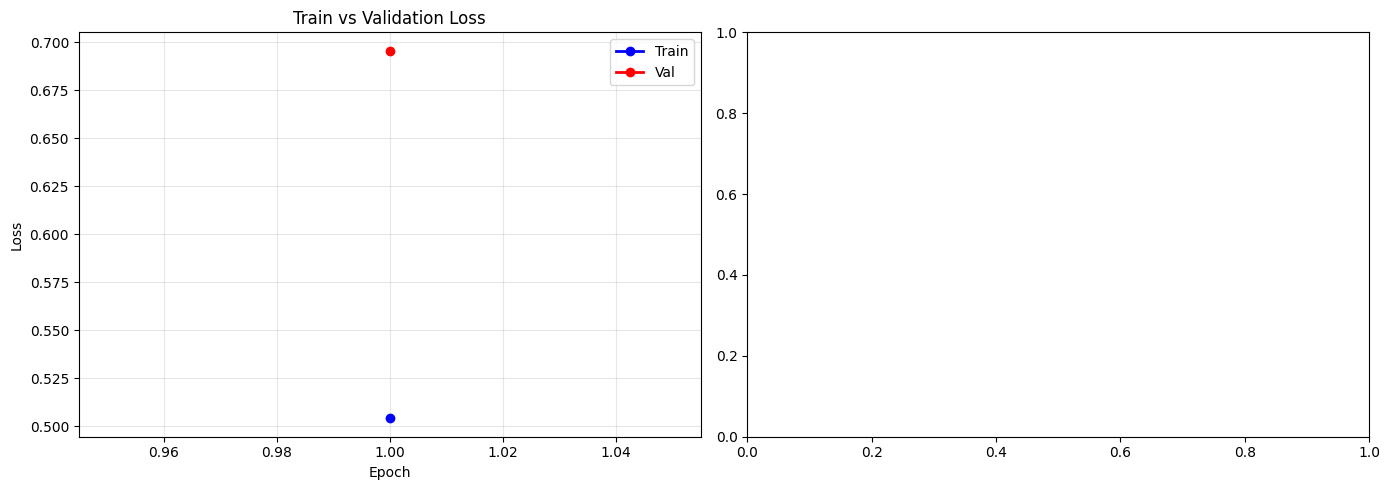

Loss curves saved


In [39]:
# Plot Loss Curves
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["epochs"], history["train_loss"], "b-o", label="Train", linewidth=2)
axes[0].plot(history["epochs"], history["val_loss"],   "r-o", label="Val",   linewidth=2)
axes[0].set_title("Train vs Validation Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
if len(history["train_loss"]) > 1:
    improvement = [history["train_loss"][0] - l for l in history["train_loss"]]
    axes[1].bar(history["epochs"], improvement, color="steelblue", alpha=0.7)
    axes[1].set_title("Loss Improvement"); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss curves saved")

In [40]:
# Merge LoRA into base model (preferred: standalone model, no peft needed at inference)
from peft import PeftModel
print("Loading base for merge...")
base   = Qwen2VLForConditionalGeneration.from_pretrained(BASE_MODEL_ID, torch_dtype=torch.float16, device_map="auto")
merged = PeftModel.from_pretrained(base, f"{OUTPUT_DIR}/epoch_{EPOCHS}")
merged = merged.merge_and_unload()
MERGED_DIR = "/kaggle/working/merged_model"
merged.save_pretrained(MERGED_DIR); processor.save_pretrained(MERGED_DIR)
print(f"Merged model saved to {MERGED_DIR}")

Loading base for merge...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Merged model saved to /kaggle/working/merged_model


In [43]:
# Upload to HuggingFace
from huggingface_hub import HfApi
api = HfApi(token=hf_token)
api.create_repo(repo_id=HF_REPO_ID, exist_ok=True)
print(f"Uploading to {HF_REPO_ID}...")
merged.push_to_hub(HF_REPO_ID, token=hf_token)
processor.push_to_hub(HF_REPO_ID, token=hf_token)
print(f"Live at: https://huggingface.co/{HF_REPO_ID}")

Uploading to Devildarker6789/qwen2vl-chartqa...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Live at: https://huggingface.co/Devildarker6789/qwen2vl-chartqa


In [45]:
# Inference Demo — pull from HuggingFace and run
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
from PIL import Image
import torch

proc_inf  = AutoProcessor.from_pretrained(HF_REPO_ID, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)
model_inf = Qwen2VLForConditionalGeneration.from_pretrained(HF_REPO_ID, torch_dtype=torch.float16, device_map="auto")
model_inf.eval()

def run_inference(image, question):
    if not isinstance(image, Image.Image): image = Image.fromarray(image)
    image = image.convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": question}
    ]}]
    text   = proc_inf.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = proc_inf(text=[text], images=[image], return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model_inf.generate(**inputs, max_new_tokens=64, do_sample=False)
    return proc_inf.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

for i in range(3):
    s  = raw_val[i]
    gt = s['label'][0] if isinstance(s['label'], list) else s['label']
    print(f"Q: {s['query']}")
    print(f"GT: {gt} | Pred: {run_inference(s['image'], s['query'])}\n")

Q: What's the color of graph with 56 as the highest value?


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


GT: Blue | Pred: Green

Q: In which year the difference between blue and green graph 1?
GT: 2018 | Pred: 2017

Q: What does the blue line represent?
GT: Not too much/not at all | Pred: Not too much/ not at all

